<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/SimpleLinearRegressionModeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 2. UPLOAD DATASET
# =========================

from google.colab import files
uploaded = files.upload()

Saving cleaned_garment_data.csv to cleaned_garment_data.csv


In [5]:
df = pd.read_csv("cleaned_garment_data.csv")
df["date"] = pd.to_datetime(df["date"])

unique_dates = sorted(df["date"].unique())
split_index = int(0.8 * len(unique_dates))
cutoff_date = unique_dates[split_index]

train = df[df["date"] < cutoff_date].copy()
test = df[df["date"] >= cutoff_date].copy()

X_train = train.drop(columns=["actual_productivity", "date", "low_productivity"])
y_train = train["actual_productivity"]

X_test = test.drop(columns=["actual_productivity", "date", "low_productivity"])
y_test = test["actual_productivity"]

numeric_cols = [
    "targeted_productivity",
    "smv",
    "wip",
    "over_time",
    "incentive",
    "idle_time",
    "idle_men",
    "no_of_style_change",
    "no_of_workers",
    "incentive_wip",
    "wip_workers",
    "incentive_workers"
]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [6]:
# =========================
# 14. TRAIN LINEAR REGRESSION MODEL
# =========================

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [7]:
# =========================
# 15. MAKE PREDICTIONS
# =========================

y_pred = linear_model.predict(X_test)

# =========================
# 16. EVALUATE MODEL
# =========================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
MAE: 0.578930445759168
RMSE: 2.8188077117320542
R2 Score: -302.51133898360524


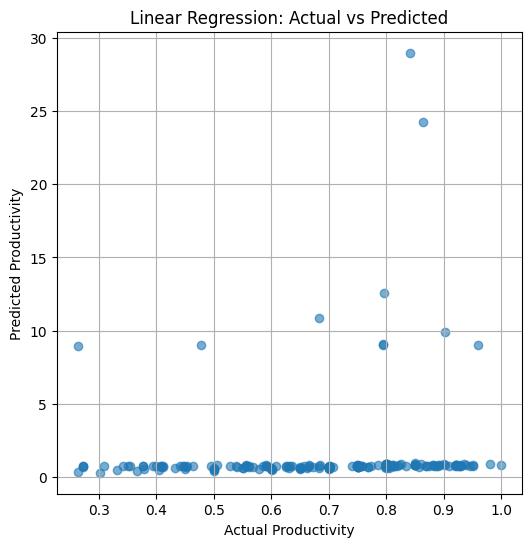

In [8]:
# =========================
# 17. ACTUAL VS PREDICTED GRAPH
# =========================

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title("Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()

In [9]:
# =========================
# 18. FEATURE COEFFICIENTS
# =========================

coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": linear_model.coef_
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)

print(coefficients)

                  Feature  Coefficient
4               incentive     0.301040
13            wip_missing     0.196441
8           no_of_workers     0.154664
0   targeted_productivity     0.041526
2                     wip     0.030753
15           day_Saturday     0.018936
18            day_Tuesday     0.012200
9           incentive_wip     0.008463
5               idle_time     0.006664
7      no_of_style_change    -0.000023
17           day_Thursday    -0.003941
12                   team    -0.005864
16             day_Sunday    -0.007134
19          day_Wednesday    -0.007230
3               over_time    -0.017436
6                idle_men    -0.018056
10            wip_workers    -0.039862
1                     smv    -0.042255
14      department_sweing    -0.196441
11      incentive_workers    -0.196762


In [10]:
# =========================
# 19. TOP POSITIVE AND NEGATIVE FACTORS
# =========================

print("Top Positive Factors:")
print(coefficients.head(10))

print("\nTop Negative Factors:")
print(coefficients.tail(10))

Top Positive Factors:
                  Feature  Coefficient
4               incentive     0.301040
13            wip_missing     0.196441
8           no_of_workers     0.154664
0   targeted_productivity     0.041526
2                     wip     0.030753
15           day_Saturday     0.018936
18            day_Tuesday     0.012200
9           incentive_wip     0.008463
5               idle_time     0.006664
7      no_of_style_change    -0.000023

Top Negative Factors:
              Feature  Coefficient
17       day_Thursday    -0.003941
12               team    -0.005864
16         day_Sunday    -0.007134
19      day_Wednesday    -0.007230
3           over_time    -0.017436
6            idle_men    -0.018056
10        wip_workers    -0.039862
1                 smv    -0.042255
14  department_sweing    -0.196441
11  incentive_workers    -0.196762


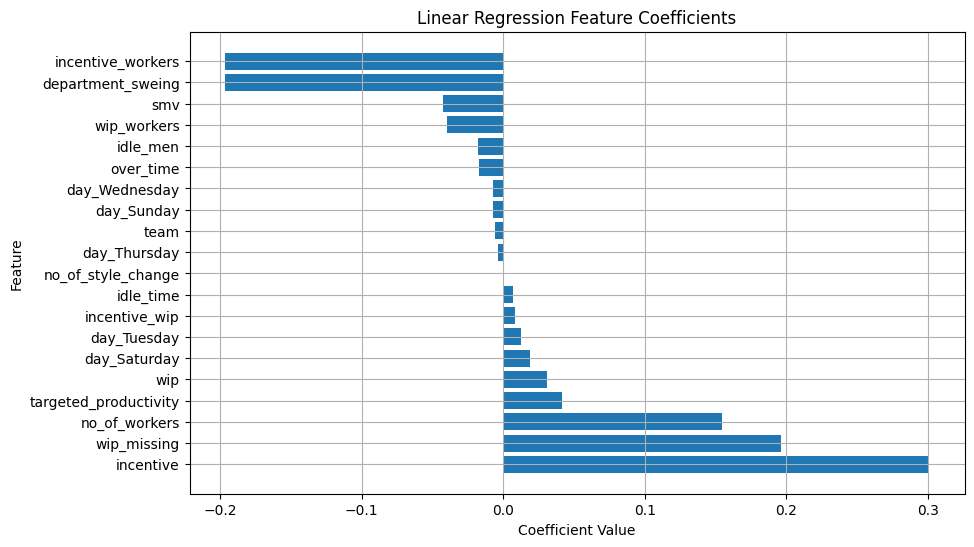

In [11]:
# =========================
# 20. COEFFICIENT BAR CHART
# =========================

plt.figure(figsize=(10,6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Linear Regression Feature Coefficients")
plt.grid(True)
plt.show()

The linear regression model was used as a baseline. However, the results show a very low R² value, indicating that productivity cannot be explained using simple linear relationships. This suggests the presence of complex and non-linear interactions in the data.